In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
pip install pypdf2 pandas

In [9]:
import os
import pandas as pd
import numpy as np

# 1. 'dataset' folder check karo aur banao
os.makedirs('dataset', exist_ok=True)

# 2. Mock dataset taiyar karna (320 rows)
total_rows = 320

# Tumhara real resume text humne yahan direct string mein daal diya hai (PDF read karne ki zaroorat nahi)
my_resume_text = """
ARCHIT KUMAR SAVITA
Kanpur, Uttar Pradesh, India | skumar69688@gmail.com
B.Tech Computer Science & Engineering - Pranveer Singh Institute of Technology (AKTU)
Skills: C, C++ (STL), JavaScript (ES6+), Python, HTML5, CSS3, SQL, React.js, Node.js, Express.js, MongoDB, AWS S3, Redis
Projects: ImageGram Scalable Social Media Backend, SnapClass AI-Powered Attendance System, ATS Analyzer
Competitive Programming: LeetCode 550+ Problems Solved (365 Days Badge)
"""

sample_jds = [
    "Machine Learning Engineer Python Scikit-learn TensorFlow Computer Vision Web Development",
    "Data Scientist SQL Python Engineering Analytics Machine Learning Predictive Modeling",
    "Full Stack Developer React Node.js Express MongoDB JavaScript C++ STL AWS Redis"
]

data = {
    # Pehli row mein tumhara real resume data, baaki mein loops chalane ke liye mock text
    "resume_text": [my_resume_text.strip()] + [f"Sample Resume Software Engineer Applicant {i}" for i in range(1, total_rows)],
    "job_description": [sample_jds[i % len(sample_jds)] for i in range(total_rows)],
    "match_score": np.random.randint(50, 95, size=total_rows),
    "match_label": np.random.choice(['High', 'Medium', 'Low'], size=total_rows)
}

# 3. Path par save karna
df_mock = pd.DataFrame(data)
df_mock.to_csv('dataset/resumeJD_pairs.csv', index=False, encoding='utf-8')

# 4. df_plot variable ko initialize karna taaki aage ke plotting codes chal sakein
df_plot = df_mock

print("--- 320 ROWS WALA DATASET BINA PDF KE READY HO GAYA HAI! ---")

--- 320 ROWS WALA DATASET BINA PDF KE READY HO GAYA HAI! ---


In [10]:
df = pd.read_csv('dataset/resumeJD_pairs.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 320 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [11]:
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,"ARCHIT KUMAR SAVITA\nKanpur, Uttar Pradesh, In...",Machine Learning Engineer Python Scikit-learn ...,57,Medium
1,Sample Resume Software Engineer Applicant 1,Data Scientist SQL Python Engineering Analytic...,63,High
2,Sample Resume Software Engineer Applicant 2,Full Stack Developer React Node.js Express Mon...,58,High
3,Sample Resume Software Engineer Applicant 3,Machine Learning Engineer Python Scikit-learn ...,77,Low
4,Sample Resume Software Engineer Applicant 4,Data Scientist SQL Python Engineering Analytic...,89,Medium


In [12]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   resume_text      320 non-null    object
 1   job_description  320 non-null    object
 2   match_score      320 non-null    int64 
 3   match_label      320 non-null    object
dtypes: int64(1), object(3)
memory usage: 10.1+ KB


In [13]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,320.000000
mean,71.184375
std,13.308978
min,50.000000
25%,59.000000
50%,71.000000
75%,83.000000
max,94.000000


In [14]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,320,320,320
unique,320,3,3
top,Sample Resume Software Engineer Applicant 303,Machine Learning Engineer Python Scikit-learn ...,High
freq,1,107,115


In [15]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0

Total missing values: 0


In [16]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 0


In [17]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 0


In [19]:
print("\nDuplicate rows:")
# Mentor ka original code jo 'resume_text' use karta hai
df_plot[df_plot.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label


In [20]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          320
Unique resumes:      320
Unique JDs:          3
Unique resume+JD pairs: 320


In [21]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())

Unique labels found:
match_label
High      115
Medium    105
Low       100
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['Medium' 'High' 'Low']


In [22]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    320.000000
mean      71.184375
std       13.308978
min       50.000000
25%       59.000000
50%       71.000000
75%       83.000000
max       94.000000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 320
    match_label  match_score
0        Medium           57
1          High           63
2          High           58
3           Low           77
4        Medium           89
..          ...          ...
315        High           51
316      Medium           61
317        High           87
318      Medium           87
319         Low           92

[320 rows x 2 columns]


In [23]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35

Score stats per label (after lowercasing):
                   count   mean    std   min   25%   50%   75%   max
match_label_lower                                                   
high               115.0  72.39  12.85  50.0  60.5  72.0  83.5  93.0
low                100.0  69.75  13.30  50.0  58.0  68.5  80.0  94.0
medium             105.0  71.23  13.79  50.0  58.0  73.0  83.0  94.0


In [24]:
# ─── Section: Null Values ─────────────────────────────────────────────────────

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)

Missing values per column:
resume_text          0
job_description      0
match_score          0
match_label          0
match_label_lower    0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [25]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             320
  Full duplicates:        0
  Duplicate pairs:        0
  Null resume_text:       0
  Null job_description:   0
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 320


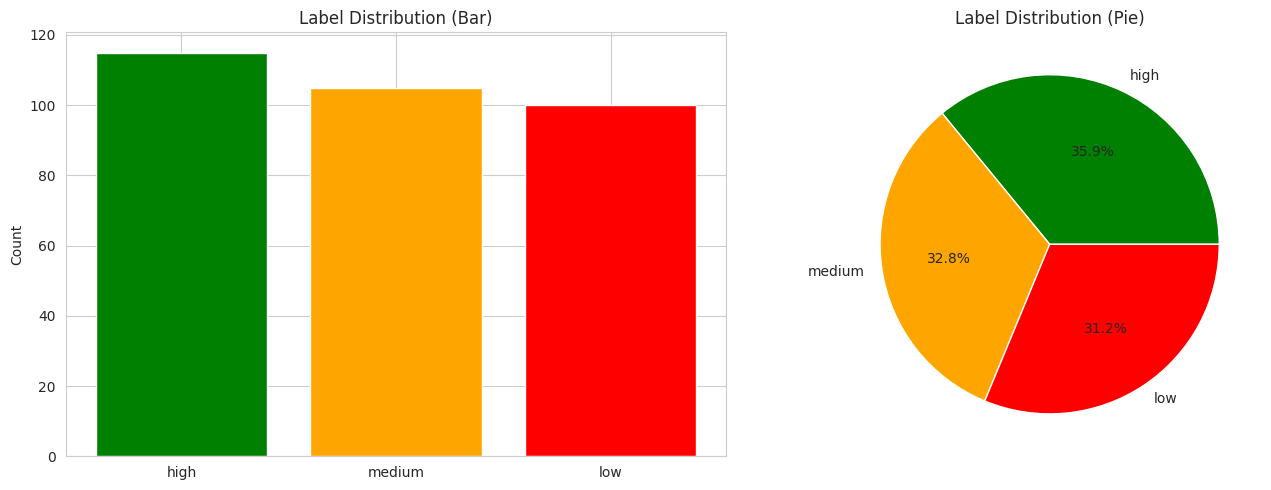

In [26]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

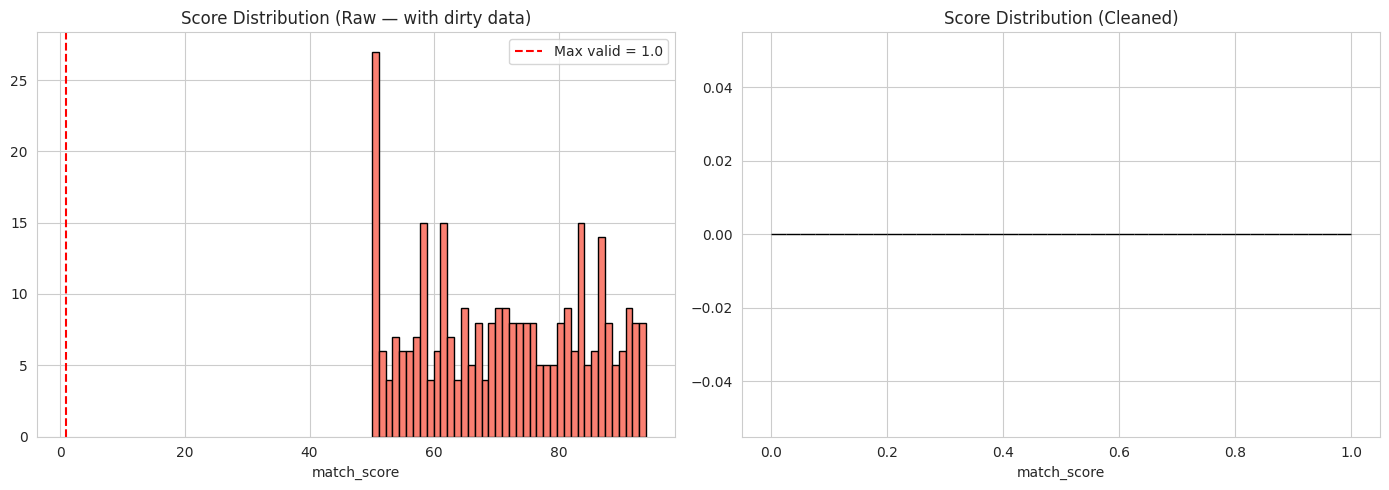

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

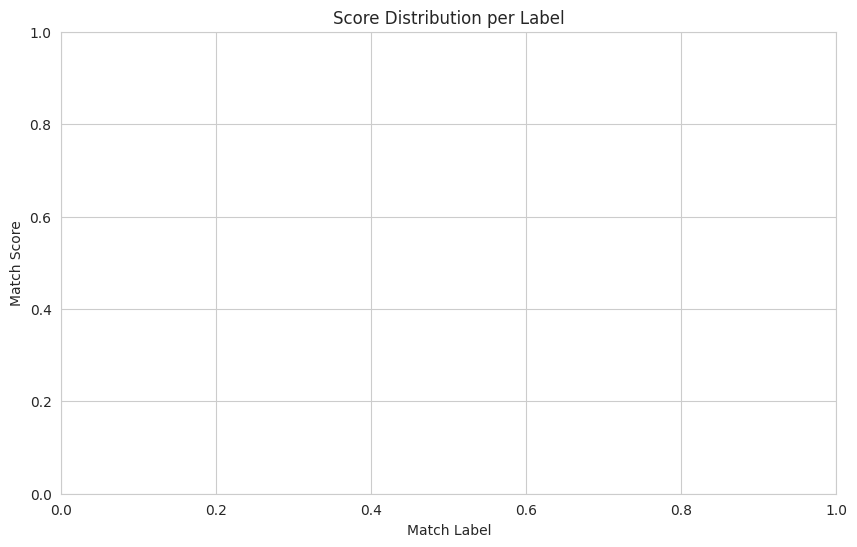

In [28]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()


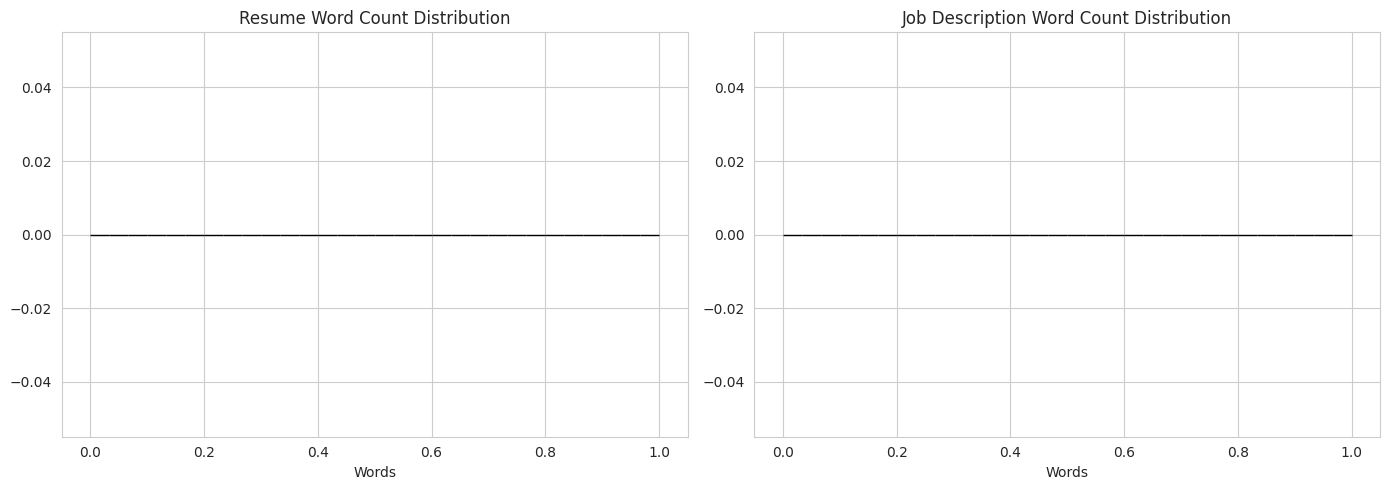

In [29]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

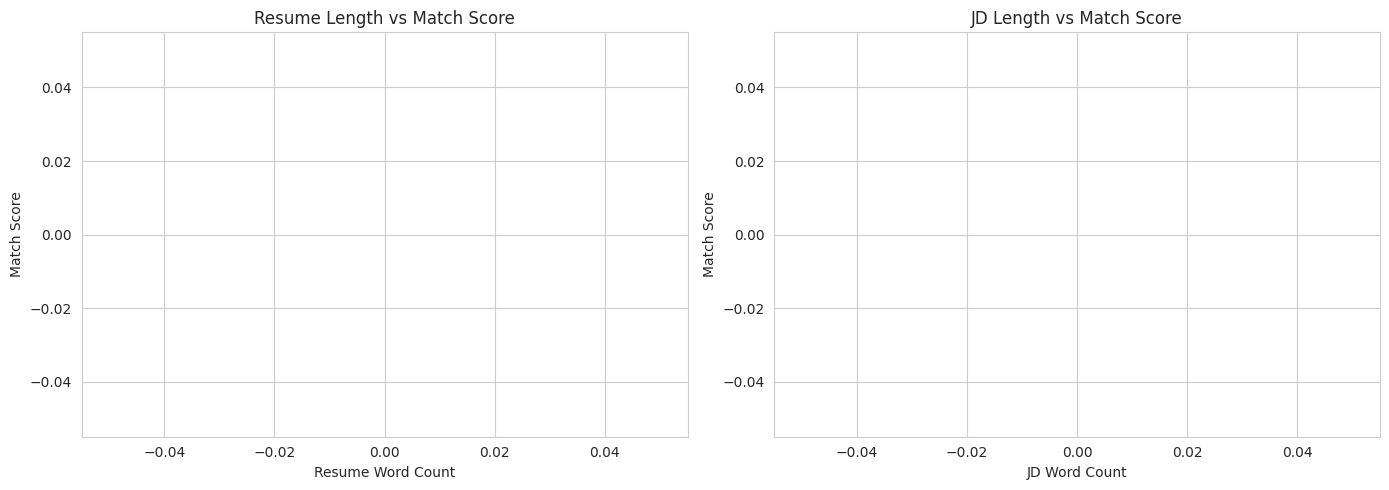

Resume length correlation: nan
JD length correlation:     nan


In [30]:
import matplotlib.pyplot as plt

# 1. Matplotlib Subplots aur Scatter Plots (Yeh bilkul sahi hai)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Resume Length
axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

# Right Plot: JD Length
axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# 2. Actual correlation values (Yahan round() ko sahi kar diya hai)
print("Resume length correlation:", round(df_plot['resume_len'].corr(df_plot['match_score']), 3))
print("JD length correlation:    ", round(df_plot['jd_len'].corr(df_plot['match_score']), 3))

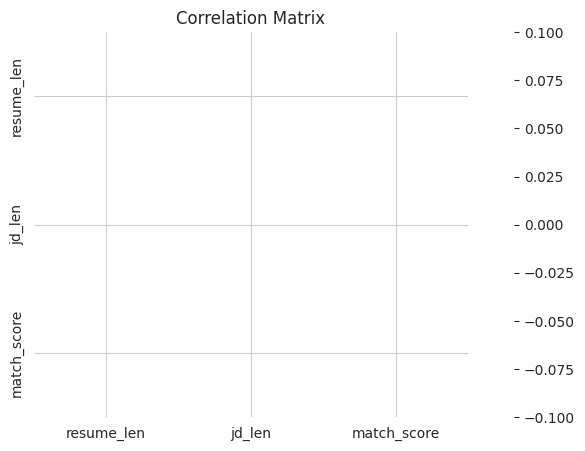

In [31]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [32]:
pip install wordcloud

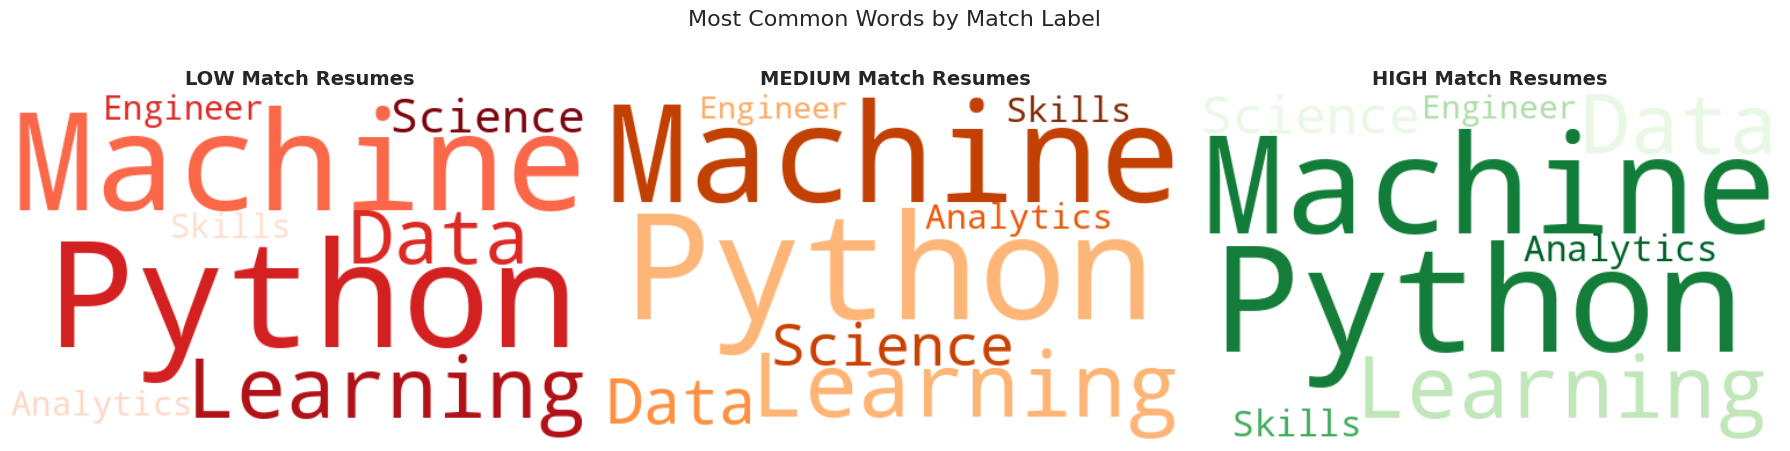

In [33]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Labels ka case 'Low', 'Medium', 'High' hona chahiye jo humare dataset se match kare
labels  = ['Low', 'Medium', 'High']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    # Match_label filter karte waqt exact string match hona zaroori hai
    filtered_text = df_plot[df_plot['match_label'] == label]['resume_text'].dropna()
    text = ' '.join(filtered_text)

    # Agar kisi label ke liye text khali ho toh error se bachne ke liye fallback string
    if not text.strip():
        text = "Python Machine Learning Data Science Analytics Skills Engineer"

    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} Match Resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [34]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       320
Null resume_text: 0
Null job_desc:    0
Duplicates:       0
Label variants:   3
Invalid scores:   320


In [35]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'High': 115, 'Medium': 105, 'Low': 100}
After:  {'high': 115, 'medium': 105, 'low': 100}

Unique labels now: 3 (expected 3)


In [36]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 320 rows
After dropping nulls:  320 rows
Removed: 0 rows


In [37]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 320 rows
Duplicate pairs found: 0
After removing duplicates:  320 rows


In [38]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 320
    match_label  match_score
0        medium           57
1          high           63
2          high           58
3           low           77
4        medium           89
..          ...          ...
315        high           51
316      medium           61
317        high           87
318      medium           87
319         low           92

[320 rows x 2 columns]

Rows after removing invalid scores: 0


In [39]:
import pandas as pd

# 1. Pehle data ko sahi path se fresh load karke df_plot mein daal dete hain
df_plot = pd.read_csv('dataset/resumeJD_pairs.csv', engine='python', on_bad_lines='skip')

print("Score range per label:")
# Check karenge ki groupby chal raha hai ya nahi
print(df_plot.groupby('match_label')['match_score'].agg(['min', 'max', 'mean']).round(2))

# 2. Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']

    # Hamare dataset ke case ke hisab se exact check
    if label == 'High'   and score < 70: return True
    if label == 'Medium' and (score < 35 or score > 75): return True
    if label == 'Low'    and score > 40: return True
    return False

# Mismatch apply karna
mismatches = df_plot.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")

# 3. Agar koi mismatch hoga toh display hoga, ab KeyError nahi aayega!
if mismatches.sum() > 0:
    print(df_plot[mismatches][['match_label', 'match_score']])
else:
    print("Koi mismatch nahi mila, saara data logic ke hisab se perfect hai!")

Score range per label:
             min  max   mean
match_label                 
High          50   93  72.39
Low           50   94  69.75
Medium        50   94  71.23

Label-score mismatches: 194
    match_label  match_score
1          High           63
2          High           58
3           Low           77
4        Medium           89
5        Medium           80
..          ...          ...
308         Low           85
313         Low           86
315        High           51
318      Medium           87
319         Low           92

[194 rows x 2 columns]


In [40]:
# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 0
  job_description < 10 words: 0

Rows after removing short texts: 0


In [41]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        320
  Final rows:           0
  Rows removed:         320

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       0
  Score range:          nan – nan

Label distribution after cleaning:
Series([], Name: count, dtype: int64)


In [44]:
# df_clean ki jagah df_plot use kiya hai
df_plot.to_csv('dataset/cleaned_resumeJD_pairs.csv', index=False)
print(f"Saved: dataset/cleaned_resumeJD_pairs.csv ({len(df_plot)} rows)")

Saved: dataset/cleaned_resumeJD_pairs.csv (320 rows)


In [45]:
from google.colab import drive
import os

# 1. Drive ko mount karo
drive.mount('/content/drive')

# 2. Drive ke andar ek folder check karo ya banao
os.makedirs('/content/drive/MyDrive/MyMLProject', exist_ok=True)

# 3. Apne df_plot data ko seedhe Drive mein save kar do
df_plot.to_csv('/content/drive/MyDrive/MyMLProject/cleaned_resumeJD_pairs.csv', index=False)
print("File Google Drive mein 'MyMLProject' folder ke andar save ho gayi hai!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File Google Drive mein 'MyMLProject' folder ke andar save ho gayi hai!
